In [8]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Point to project root so imports and relative paths stay clean
sys.path.append(os.path.abspath('..'))

# Load the saved multivariate matrix (loads in under 1 second)
data_path = '../data/ssl_pretraining/lcl_2013_multivariate.csv'
df = pd.read_csv(data_path, index_col=0, parse_dates=True)

print("Loaded Clean LCL 2013 Matrix:", df.shape)
df.head()

Loaded Clean LCL 2013 Matrix: (17520, 25)


,MAC000002,MAC000010,MAC000049,MAC000060,MAC001179,MAC001202,MAC001206,MAC002862,MAC002863,MAC002876,...,MAC002934,MAC002940,MAC002949,MAC002962,MAC002966,MAC002974,MAC002979,MAC005191,MAC005470,MAC005474
DateTime,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.219,0.509,0.590,0.310,0.206,0.928,0.019,0.260,0.024,0.116,...,0.031,0.009,0.027,0.621,0.222,0.049,0.135,0.090,0.105,0.046
2013-01-01 00:30:00,0.241,0.453,0.519,0.123,0.194,1.036,0.053,0.139,0.021,0.163,...,0.020,0.046,0.027,0.518,0.200,0.032,0.066,0.118,0.087,0.037
2013-01-01 01:00:00,0.191,0.500,0.486,0.225,0.217,0.072,0.046,0.072,0.033,0.155,...,0.020,0.009,0.040,0.610,0.105,0.052,0.022,0.144,0.050,0.014
2013-01-01 01:30:00,0.235,0.621,0.237,0.062,0.108,0.071,0.027,0.055,0.034,0.174,...,0.063,0.008,0.016,0.604,0.089,0.028,0.024,0.090,0.045,0.007
2013-01-01 02:00:00,0.182,0.197,0.500,0.042,0.084,0.070,0.053,0.057,0.033,0.156,...,0.059,0.028,0.035,0.602,0.067,0.053,0.052,0.065,0.061,0.019


In [9]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure paths
sys.path.append(os.path.abspath('..'))
data_path = Path('../data/ssl_pretraining/lcl_2013_multivariate.csv')
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# Set plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11

# Load clean matrix
df = pd.read_csv(data_path, index_col=0, parse_dates=True)
print(f"Loaded matrix shape: {df.shape}")
df.head(3)

Loaded matrix shape: (17520, 25)


,MAC000002,MAC000010,MAC000049,MAC000060,MAC001179,MAC001202,MAC001206,MAC002862,MAC002863,MAC002876,...,MAC002934,MAC002940,MAC002949,MAC002962,MAC002966,MAC002974,MAC002979,MAC005191,MAC005470,MAC005474
DateTime,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.219,0.509,0.590,0.310,0.206,0.928,0.019,0.260,0.024,0.116,...,0.031,0.009,0.027,0.621,0.222,0.049,0.135,0.090,0.105,0.046
2013-01-01 00:30:00,0.241,0.453,0.519,0.123,0.194,1.036,0.053,0.139,0.021,0.163,...,0.020,0.046,0.027,0.518,0.200,0.032,0.066,0.118,0.087,0.037
2013-01-01 01:00:00,0.191,0.500,0.486,0.225,0.217,0.072,0.046,0.072,0.033,0.155,...,0.020,0.009,0.040,0.610,0.105,0.052,0.022,0.144,0.050,0.014


In [10]:
print("--- LCL 2013 Structural Audit ---")
print(f"1. Number of Households (Channels): {df.shape[1]}")
print(f"2. Total Number of Timestamps:      {df.shape[0]}")

# 3. Sampling Frequency check
inferred_freq = pd.infer_freq(df.index)
time_diffs = df.index.to_series().diff().dropna().value_counts()
print(f"3. Inferred Frequency:             {inferred_freq}")
print(f"   Delta breakdown:\n{time_diffs}\n")

# 4. Missing values
null_count = df.isnull().sum().sum()
print(f"4. Total Missing (NaN) Values:     {null_count}")

# 5. Duplicate timestamps
dup_count = df.index.duplicated().sum()
print(f"5. Duplicate Timestamps:           {dup_count}")

# 6. Missing timestamps across continuous range
expected_range = pd.date_range(start='2013-01-01 00:00:00', end='2013-12-31 23:30:00', freq='30min')
missing_timestamps = expected_range.difference(df.index)
print(f"6. Missing Timestamps in 2013:     {len(missing_timestamps)}")

--- LCL 2013 Structural Audit ---
1. Number of Households (Channels): 25
2. Total Number of Timestamps:      17520
3. Inferred Frequency:             30min
   Delta breakdown:
DateTime
0 days 00:30:00    17519
Name: count, dtype: int64

4. Total Missing (NaN) Values:     0
5. Duplicate Timestamps:           0
6. Missing Timestamps in 2013:     0


,Mean (kWh),Std (kWh),Min (kWh),Median (kWh),Max (kWh)
MAC000002,0.240562,0.239667,0.065,0.150,2.994
MAC000010,0.531331,0.415648,0.113,0.394,4.189
MAC000049,0.730193,0.673872,0.098,0.470,6.171
MAC000060,0.220926,0.207013,0.017,0.143,2.036
MAC001179,0.241309,0.205841,0.029,0.209,2.835
MAC001202,0.637425,0.500913,0.032,0.574,4.038
MAC001206,0.106372,0.105924,0.015,0.087,1.168
MAC002862,0.378885,0.494742,0.010,0.178,3.326
MAC002863,0.044489,0.092545,0.000,0.023,1.725
MAC002876,0.139778,0.134067,0.000,0.087,1.518


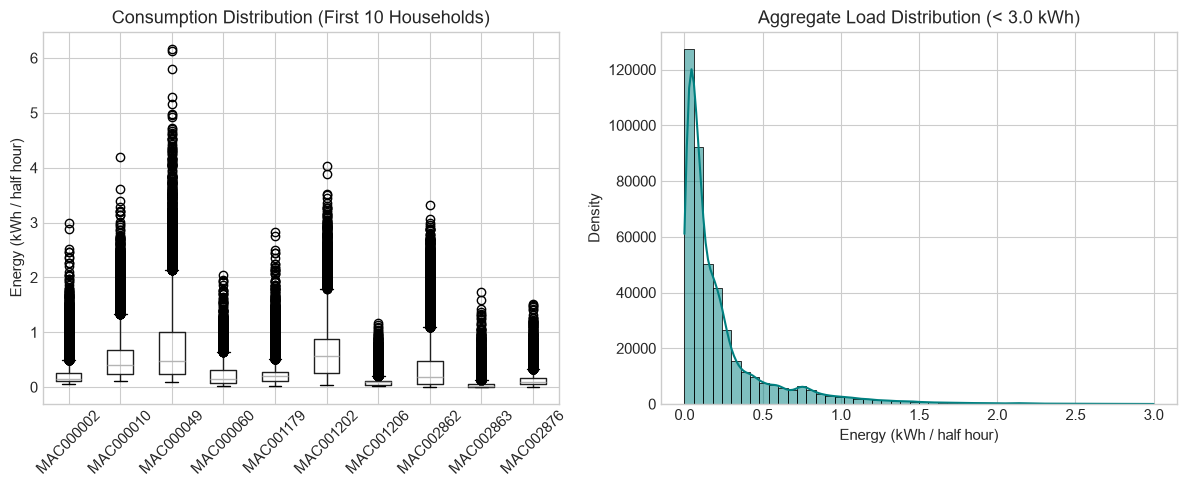

In [11]:
# Statistical summary across households
summary_stats = df.describe().T[['mean', 'std', 'min', '50%', 'max']]
summary_stats.columns = ['Mean (kWh)', 'Std (kWh)', 'Min (kWh)', 'Median (kWh)', 'Max (kWh)']
display(summary_stats.head(10))

# Distribution Boxplot & KDE
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df.iloc[:, :10].boxplot(rot=45)
plt.title("Consumption Distribution (First 10 Households)")
plt.ylabel("Energy (kWh / half hour)")

plt.subplot(1, 2, 2)
flat_vals = df.values.flatten()
sns.histplot(flat_vals[flat_vals < 3.0], bins=50, kde=True, color='teal')
plt.title("Aggregate Load Distribution (< 3.0 kWh)")
plt.xlabel("Energy (kWh / half hour)")
plt.ylabel("Density")

plt.tight_layout()
plt.savefig(fig_dir / "lcl_consumption_distribution.png", dpi=300)
plt.show()

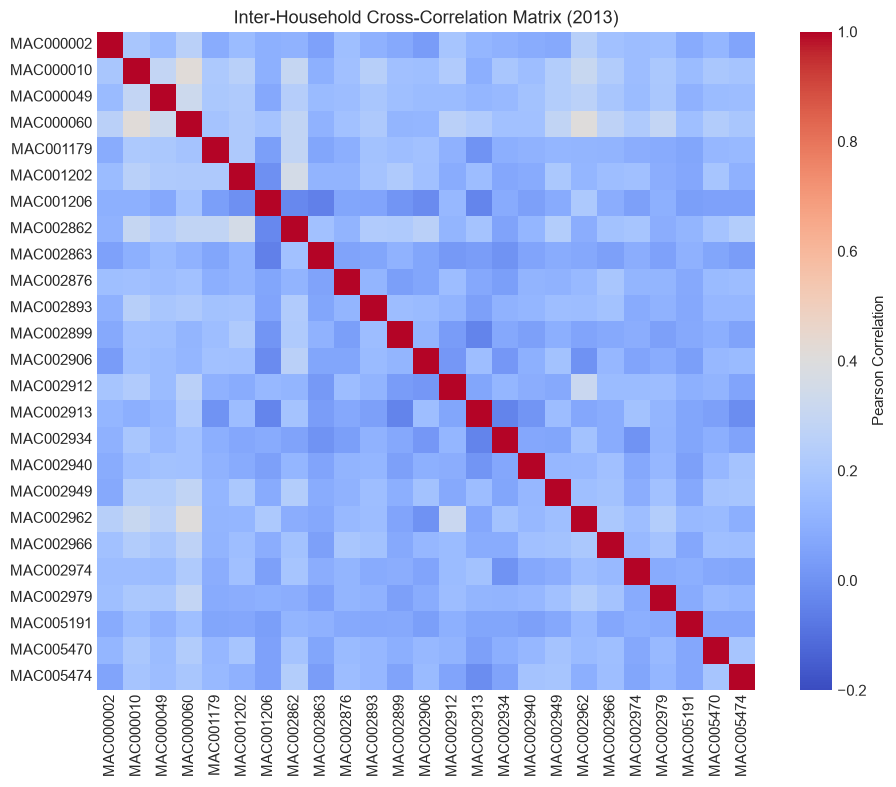

Average pairwise correlation between households: 0.130


In [12]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    cmap='coolwarm', 
    vmin=-0.2, 
    vmax=1.0, 
    square=True, 
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title("Inter-Household Cross-Correlation Matrix (2013)")
plt.tight_layout()
plt.savefig(fig_dir / "lcl_correlation_heatmap.png", dpi=300)
plt.show()

mean_corr = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean()
print(f"Average pairwise correlation between households: {mean_corr:.3f}")

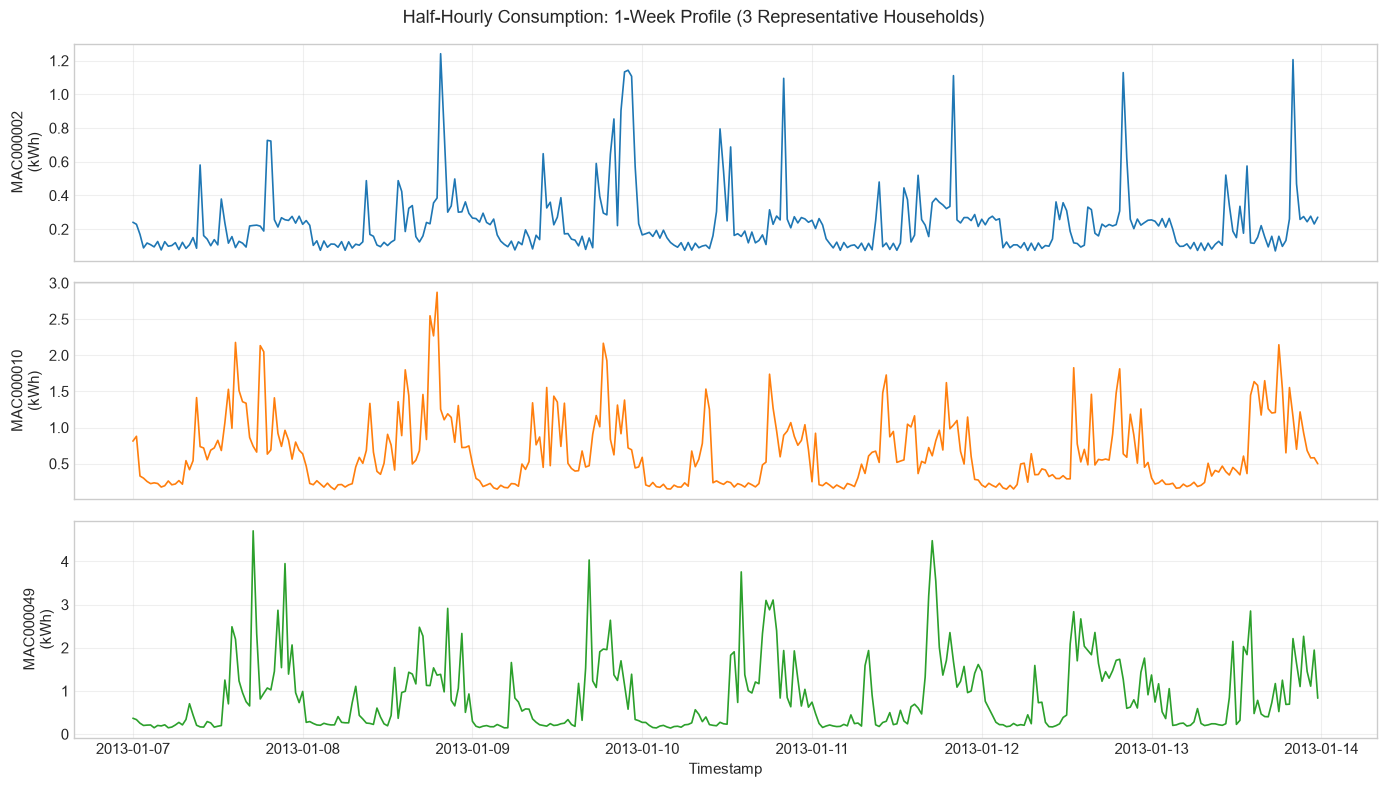

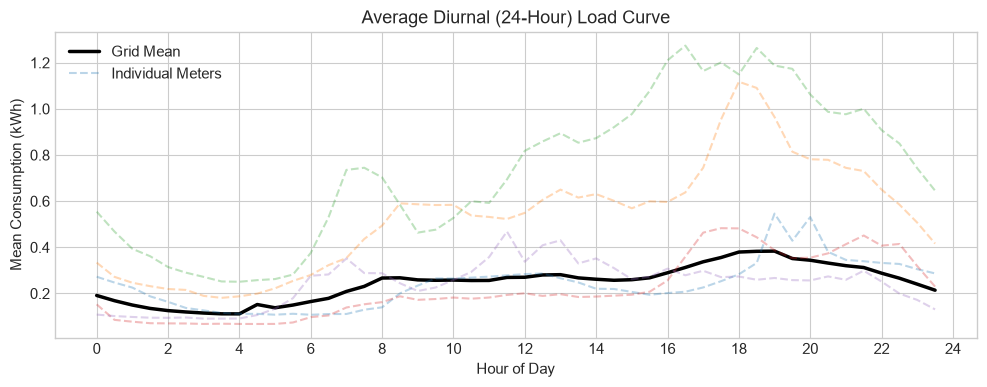

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# Select one representative week in January 2013
week_sample = df.loc['2013-01-07':'2013-01-13']
channels_to_plot = df.columns[:3]

for i, col in enumerate(channels_to_plot):
    axes[i].plot(week_sample.index, week_sample[col], color=f"C{i}", lw=1.2)
    axes[i].set_ylabel(f"{col}\n(kWh)")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Timestamp")
plt.suptitle("Half-Hourly Consumption: 1-Week Profile (3 Representative Households)", y=0.98)
plt.tight_layout()
plt.savefig(fig_dir / "lcl_timeseries_one_week.png", dpi=300)
plt.show()

# Diurnal (24-hour) Profile
df['Hour'] = df.index.hour + df.index.minute / 60.0
hourly_profile = df.groupby('Hour').mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_profile.index, hourly_profile.mean(axis=1), color='black', lw=2.5, label='Grid Average')
plt.plot(hourly_profile.index, hourly_profile.iloc[:, :5], alpha=0.3, ls='--')
plt.title("Average Diurnal (24-Hour) Load Curve")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Consumption (kWh)")
plt.xticks(range(0, 25, 2))
plt.legend(['Grid Mean', 'Individual Meters'])
plt.tight_layout()
plt.savefig(fig_dir / "lcl_diurnal_profile.png", dpi=300)
plt.show()

# Clean up temporary column
df.drop(columns=['Hour'], inplace=True)